In [1]:
import os
import cv2
import sklearn
import pandas as pd
import numpy as np,random
import seaborn as sn
import tensorflow as tf
from sklearn.svm import SVC
from keras.optimizers import Adam
from sklearn.utils import shuffle
from sklearn.svm import LinearSVC
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras import layers 
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.layers import BatchNormalization,MaxPooling2D,Conv2D,Flatten,Dense,Dropout


In [2]:
def safe_mri_augment1(img):
    h, w = img.shape[:2]

    # 1. Fixed rotation (+7° clockwise)
    angle = 7
    M_rot = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    img = cv2.warpAffine(img, M_rot, (w, h), borderMode=cv2.BORDER_REFLECT)

    # 2. Fixed zoom (1.08x zoom-in)
    zf = 1.08
    zh, zw = int(h * zf), int(w * zf)
    img = cv2.resize(img, (zw, zh))
    start_y = (zh - h) // 2
    start_x = (zw - w) // 2
    img = img[start_y:start_y + h, start_x:start_x + w]

    # 3. Fixed gamma correction (brighten slightly)
    gamma = 1.15
    img = np.power(img / 255.0, gamma) * 255
    img = img.astype(np.uint8)

    # 4. Fixed Gaussian noise (mean=0, std=5)
    rng = np.random.RandomState(42)  # fixed seed -> always same noise
    noise = rng.normal(0, 5, img.shape).astype(np.int16)
    img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    return img


def rf_augmentation(img):
    img = img.astype(np.float32) / 255.0
    h, w = img.shape[:2]

    # same zoom
    zf = 1.012
    zh, zw = int(h * zf), int(w * zf)
    img = cv2.resize(img, (zw, zh))
    sy, sx = (zh - h)//2, (zw - w)//2
    img = img[sy:sy+h, sx:sx+w]

    # gamma a bit stronger (1.06)
    gamma = 1.06
    img = np.power(img, gamma)

    # CLAHE stronger (clipLimit=2.0)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = (clahe.apply((img*255).astype(np.uint8)) / 255.0).astype(np.float32)

    # no noise
    return (img*255).astype(np.uint8)


def safe_mri_augment3(img):
    h, w = img.shape[:2]

    # Fixed rotation (+7°)
    M_rot = cv2.getRotationMatrix2D((w//2, h//2), 7, 1.0)
    img = cv2.warpAffine(img, M_rot, (w, h), borderMode=cv2.BORDER_REFLECT)

    # Zoom 1.08x
    zf = 1.08
    zh, zw = int(h*zf), int(w*zf)
    img = cv2.resize(img, (zw, zh))
    start_y, start_x = (zh-h)//2, (zw-w)//2
    img = img[start_y:start_y+h, start_x:start_x+w]

    # Gamma correction (1.15 → darker)
    img = np.power(img/255.0, 1.15) * 255

    # Gaussian blur
    img = cv2.GaussianBlur(img.astype(np.uint8), (5,5), 0)

    # Horizontal flip
    img = cv2.flip(img, 1)

    return img


def safe_mri_augment4(img):
    h, w = img.shape[:2]

    # --- Step 1: Normalize intensity [0,1] ---
    img = img.astype(np.float32) / 255.0

    # --- Step 2: Fixed small rotation (3°) ---
    M_rot = cv2.getRotationMatrix2D((w // 2, h // 2), 3, 1.0)
    img = cv2.warpAffine(img, M_rot, (w, h), borderMode=cv2.BORDER_REFLECT)

    # --- Step 3: Slight zoom (1.02x) ---
    zf = 1.02
    zh, zw = int(h * zf), int(w * zf)
    img = cv2.resize(img, (zw, zh))
    start_y = (zh - h) // 2
    start_x = (zw - w) // 2
    img = img[start_y:start_y + h, start_x:start_x + w]

    # --- Step 4: Mild contrast stretch ---
    img = cv2.normalize(img, None, alpha=0, beta=1.0, norm_type=cv2.NORM_MINMAX)

    # --- Step 5: Gentle denoise (MRI-safe) ---
    img = cv2.GaussianBlur(img, (3,3), 0)

    # Convert back to 8-bit
    img = (img * 255).astype(np.uint8)

    return img


def safe_mri_augment5(img):
    # Ensure grayscale
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 1. Normalize to [0,1]
    img = img.astype("float32") / 255.0  

    # 2. Bias-field like correction (CLAHE improves local contrast)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply((img * 255).astype(np.uint8)) / 255.0  

    # 3. Mild denoising (Gaussian blur)
    img = cv2.GaussianBlur(img, (3, 3), 0)

    # 4. Intensity scaling (simulate scanner variability)
    img = np.clip(img * 1.05 + 0.02, 0, 1.0)

    return img

In [3]:
path_of_dir = os.listdir('../brain tumor/')
classes_in_dir = {'Brain Tumor': 1, 'Healthy': 0}

X, Y = [], []
for cls in classes_in_dir:
    path = '../brain tumor/' + cls
    for file in os.listdir(path):
        img = cv2.imread(os.path.join(path, file), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (200, 200))
        X.append(img)
        Y.append(classes_in_dir[cls])

x = np.array(X, dtype="float32")
y = np.array(Y)


In [4]:
x.shape

(4000, 200, 200)

In [5]:
pd.Series(y).value_counts()

1    2000
0    2000
Name: count, dtype: int64

In [6]:
# --------------------
# Train-test split
# --------------------
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, shuffle=True, random_state=42
)

# Cast to float32
x_train = x_train.astype("float32")
x_test  = x_test.astype("float32")

# Normalize test images to [0,1]
x_test = x_test / 255.0

# --------------------
# Augmentations
# --------------------
x_train_aug1 = np.array([safe_mri_augment1(img) for img in x_train], dtype="float32")
x_train_aug2 = np.array([rf_augmentation(img) for img in x_train], dtype="float32")
x_train_aug3 = np.array([safe_mri_augment3(img) for img in x_train], dtype="float32")
x_train_aug4 = np.array([safe_mri_augment4(img) for img in x_train], dtype="float32")
x_train_aug5 = np.array([safe_mri_augment5(img) for img in x_train], dtype="float32")

# --------------------
# Combine original + augmentation with labels
# --------------------
def combine_with_labels(x_orig, y_orig, x_aug):
    x_comb = np.concatenate([x_orig, x_aug], axis=0)
    y_comb = np.concatenate([y_orig, y_orig], axis=0)  # duplicate labels
    return x_comb, y_comb

# Create dataset variants for each model
x_train_cnn, y_train_cnn = combine_with_labels(x_train, y_train, x_train_aug1)  # CNN
x_train_rf,  y_train_rf  = combine_with_labels(x_train, y_train, x_train_aug2)  # RF
x_train_svm, y_train_svm = combine_with_labels(x_train, y_train, x_train_aug3)  # SVM
x_train_knn, y_train_knn = combine_with_labels(x_train, y_train, x_train_aug4)  # KNN
x_train_lr,  y_train_lr  = combine_with_labels(x_train, y_train, x_train_aug5)  # LR

# --------------------
# Normalize / reshape
# --------------------
# CNN: keep 4D and normalize here (assuming augmentations return 0–255)
x_train_cnn = x_train_cnn.reshape(-1, 200, 200, 1) / 255.0
x_test_cnn  = x_test.reshape(-1, 200, 200, 1)

# ML models: 2D images normalized to [0,1]
x_train_rf  = x_train_rf.reshape(-1, 200, 200) / 255.0
x_train_svm = x_train_svm.reshape(-1, 200, 200) / 255.0
x_train_knn = x_train_knn.reshape(-1, 200, 200) / 255.0
x_train_lr  = x_train_lr.reshape(-1, 200, 200) / 255.0
x_test_ml   = x_test.reshape(-1, 200, 200)   # already normalized earlier

# --------------------
# Labels
# --------------------
y_train_cnn = np.array(y_train_cnn)
y_train_rf  = np.array(y_train_rf)
y_train_svm = np.array(y_train_svm)
y_train_knn = np.array(y_train_knn)
y_train_lr  = np.array(y_train_lr)
y_test      = np.array(y_test)

# --------------------
# Check shapes
# --------------------
print("CNN Train:", x_train_cnn.shape, y_train_cnn.shape)
print("RF Train :", x_train_rf.shape,  y_train_rf.shape)
print("SVM Train:", x_train_svm.shape, y_train_svm.shape)
print("KNN Train:", x_train_knn.shape, y_train_knn.shape)
print("LR Train :", x_train_lr.shape,  y_train_lr.shape)
print("CNN Test :", x_test_cnn.shape, y_test.shape)
print("ML Test  :", x_test_ml.shape, y_test.shape)


CNN Train: (6400, 200, 200, 1) (6400,)
RF Train : (6400, 200, 200) (6400,)
SVM Train: (6400, 200, 200) (6400,)
KNN Train: (6400, 200, 200) (6400,)
LR Train : (6400, 200, 200) (6400,)
CNN Test : (800, 200, 200, 1) (800,)
ML Test  : (800, 200, 200) (800,)


In [7]:
#plt.imshow(x_test3D[5])
#plt.xlabel(y_test3D[5])


#CNN MODEL

In [8]:
cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(200,200,1)),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),   # light dropout
    Dense(1, activation='sigmoid')
])

In [9]:
cnn.compile(optimizer='adam',loss='binary_crossentropy', metrics=['accuracy'])

In [10]:
cnn.fit(x_train_cnn,y_train_cnn,validation_data=(x_test_cnn,y_test), epochs=3, batch_size=16)

Epoch 1/3
400/400 [==============================] - 112s 278ms/step - loss: 0.4087 - accuracy: 0.8108 - val_loss: 0.2423 - val_accuracy: 0.9112
Epoch 2/3
400/400 [==============================] - 111s 277ms/step - loss: 0.1618 - accuracy: 0.9438 - val_loss: 0.2064 - val_accuracy: 0.9250
Epoch 3/3
400/400 [==============================] - 107s 267ms/step - loss: 0.0601 - accuracy: 0.9822 - val_loss: 0.1883 - val_accuracy: 0.9500


In [11]:
test_loss,test_acc=cnn.evaluate(x_test_cnn,y_test,verbose=2)

25/25 - 3s - loss: 0.1883 - accuracy: 0.9500 - 3s/epoch - 128ms/step


In [12]:
pred1=(cnn.predict(x_test_cnn)>0.5).astype('int').flatten()

25/25 [==============================] - 3s 120ms/step


In [13]:
print(pred1[0:20])

[1 1 0 1 1 1 0 1 0 1 0 0 1 0 0 1 1 0 1 0]


In [14]:
accuracy_score(y_test,pred1)

0.95

In [15]:
conf_mat= confusion_matrix(y_test,pred1)
print(classification_report(y_test,pred1))


              precision    recall  f1-score   support

           0       0.96      0.94      0.95       400
           1       0.94      0.96      0.95       400

    accuracy                           0.95       800
   macro avg       0.95      0.95      0.95       800
weighted avg       0.95      0.95      0.95       800



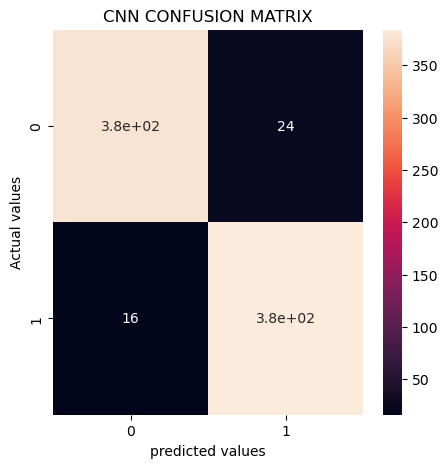

In [16]:
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("CNN CONFUSION MATRIX")
plt.show()

#Random forest

In [17]:
from skimage.feature import hog

# -----------------------------
# 1. HOG Feature Extraction
# -----------------------------
from skimage.feature import hog

def extract_hog_features1(images, pixels_per_cell=(16,16), cells_per_block=(2,2), orientations=9):
    feats = []
    for img in images:
        hog_feat = hog(img, 
                       orientations=orientations, 
                       pixels_per_cell=pixels_per_cell, 
                       cells_per_block=cells_per_block, 
                       block_norm='L2-Hys', 
                       visualize=False, 
                       feature_vector=True)
        feats.append(hog_feat)
    return np.array(feats, dtype="float32")

# -----------------------------
# 2. Extract HOG Features
# -----------------------------
X_train_hog = extract_hog_features1(x_train_rf.reshape(-1,200,200))
X_test_hog  = extract_hog_features1(x_test_ml.reshape(-1,200,200))

print("HOG train shape:", X_train_hog.shape)
print("HOG test shape :", X_test_hog.shape)

# -----------------------------
# 3. Train Random Forest on HOG features
# -----------------------------
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_hog, y_train_rf)

# -----------------------------
# 4. Predict & Evaluate
# -----------------------------
pred2 = rf.predict(X_test_hog)

print("Train  Accuracy:", rf.score(X_train_hog, y_train_rf))
print("RF (HOG) Test Accuracy:", accuracy_score(y_test, pred2))
print("\nClassification Report (HOG):\n", classification_report(y_test, pred2))


HOG train shape: (6400, 4356)
HOG test shape : (800, 4356)
Train  Accuracy: 1.0
RF (HOG) Test Accuracy: 0.96125

Classification Report (HOG):
               precision    recall  f1-score   support

           0       0.97      0.95      0.96       400
           1       0.95      0.97      0.96       400

    accuracy                           0.96       800
   macro avg       0.96      0.96      0.96       800
weighted avg       0.96      0.96      0.96       800



In [18]:

conf_mat2=confusion_matrix(y_test,pred2)


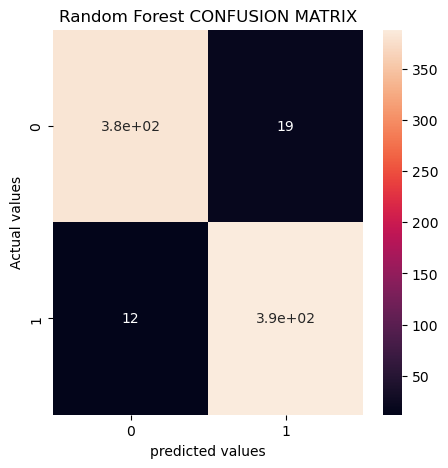

In [19]:
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat2,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Random Forest CONFUSION MATRIX")
plt.show()

#SVM

In [20]:
# -----------------------------
# HOG Feature Extraction
# -----------------------------
def extract_hog_features2(images, pixels_per_cell=(16,16), cells_per_block=(2,2), orientations=9):
    feats = []
    for img in images:
        hog_feat = hog(img, 
                       orientations=orientations, 
                       pixels_per_cell=pixels_per_cell, 
                       cells_per_block=cells_per_block, 
                       block_norm='L2-Hys', 
                       visualize=False, 
                       feature_vector=True)
        feats.append(hog_feat)
    return np.array(feats, dtype="float32")

# Reshape and prepare images
x_train_imgs = x_train_svm.reshape(-1, 200, 200)
x_test_imgs  = x_test_ml.reshape(-1, 200, 200)

# Extract HOG features
X_train_hog = extract_hog_features2(x_train_imgs)
X_test_hog  = extract_hog_features2(x_test_imgs)

print("Train shape:", X_train_hog.shape)
print("Test shape :", X_test_hog.shape)

# Train SVM
svm = SVC(kernel="rbf", C=10, gamma="scale", random_state=42)
svm.fit(X_train_hog, y_train_rf)

# Predict
pred3 = svm.predict(X_test_hog)

print("Train Accuracy:", svm.score(X_train_hog, y_train_svm))
print("Test Accuracy:", accuracy_score(y_test, pred3))
print("\nClassification Report:\n", classification_report(y_test, pred3))



Train shape: (6400, 4356)
Test shape : (800, 4356)
Train Accuracy: 1.0
Test Accuracy: 0.975

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.98       400
           1       0.98      0.97      0.97       400

    accuracy                           0.97       800
   macro avg       0.98      0.97      0.97       800
weighted avg       0.98      0.97      0.97       800



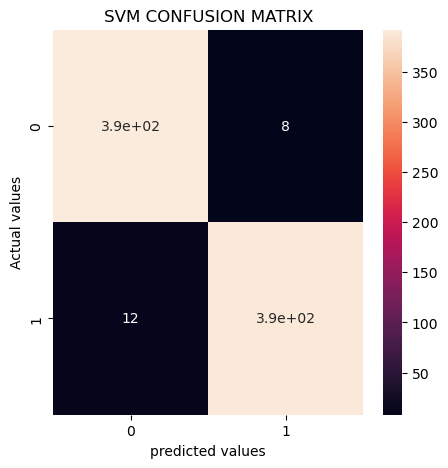

In [21]:
conf_mat3=confusion_matrix(y_test,pred3)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat3,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("SVM CONFUSION MATRIX")
plt.show()

#KNN

In [22]:
def extract_hog_features3(images, pixels_per_cell=(16,16), cells_per_block=(2,2), orientations=9):
    feats = []
    for img in images:
        hog_feat = hog(img, 
                       orientations=orientations, 
                       pixels_per_cell=pixels_per_cell, 
                       cells_per_block=cells_per_block, 
                       block_norm='L2-Hys', 
                       visualize=False, 
                       feature_vector=True)
        feats.append(hog_feat)
    return np.array(feats, dtype="float32")

# Reshape and prepare images
x_train_imgs = x_train_knn.reshape(-1, 200, 200)
x_test_imgs  = x_test_ml.reshape(-1, 200, 200)

# Extract HOG features
X_train_hog = extract_hog_features3(x_train_imgs)
X_test_hog  = extract_hog_features3(x_test_imgs)

print("Train shape:", X_train_hog.shape)
print("Test shape :", X_test_hog.shape)


# -----------------------------
# 5. KNN Classifier
# -----------------------------
knn = KNeighborsClassifier(n_neighbors=3, weights='distance',metric='manhattan')
knn.fit(X_train_hog, y_train_knn)

pred4 = knn.predict(X_test_hog)

# -----------------------------
# 6. Evaluation
# -----------------------------
print("Test Accuracy:", accuracy_score(y_test, pred4))
print("\nClassification Report:\n", classification_report(y_test, pred4))


Train shape: (6400, 4356)
Test shape : (800, 4356)
Test Accuracy: 0.97125

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97       400
           1       0.97      0.97      0.97       400

    accuracy                           0.97       800
   macro avg       0.97      0.97      0.97       800
weighted avg       0.97      0.97      0.97       800



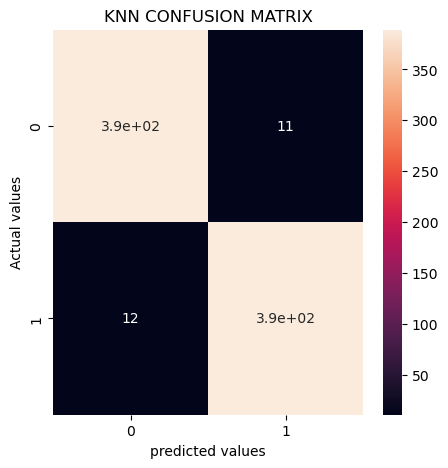

In [23]:
conf_mat4=confusion_matrix(y_test,pred4)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat4,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("KNN CONFUSION MATRIX")
plt.show()

#Logistic Regression

In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

def extract_hog_features4(images, pixels_per_cell=(16,16), cells_per_block=(2,2), orientations=9):
    feats = []
    for img in images:
        hog_feat = hog(img,
                       orientations=orientations,
                       pixels_per_cell=pixels_per_cell,
                       cells_per_block=cells_per_block,
                       block_norm='L2-Hys',
                       visualize=False,
                       feature_vector=True)
        feats.append(hog_feat)
    return np.array(feats, dtype="float32")

# -----------------------------
# Reshape and prepare images
# -----------------------------
x_train_imgs = x_train_lr.reshape(-1, 200, 200)
x_test_imgs  = x_test_ml.reshape(-1, 200, 200)

# Extract HOG features
X_train_hog = extract_hog_features4(x_train_imgs)
X_test_hog  = extract_hog_features4(x_test_imgs)

print("Raw HOG Train shape:", X_train_hog.shape)
print("Raw HOG Test  shape:", X_test_hog.shape)

LR=LogisticRegression(
        C=0.05,                                  # stronger regularization
        penalty="l2",
        solver="lbfgs",
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    )
LR.fit(X_train_hog, y_train_lr)

# Predict
pred5 = LR.predict(X_test_hog)

# -----------------------------
# Evaluation
# -----------------------------
print("Test Accuracy:", accuracy_score(y_test, pred5))
print("\nClassification Report:\n", classification_report(y_test, pred5))


Raw HOG Train shape: (6400, 4356)
Raw HOG Test  shape: (800, 4356)
Test Accuracy: 0.92375

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.91      0.92       400
           1       0.91      0.94      0.92       400

    accuracy                           0.92       800
   macro avg       0.92      0.92      0.92       800
weighted avg       0.92      0.92      0.92       800



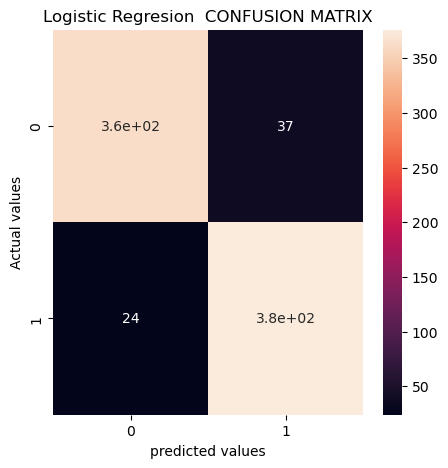

In [45]:
conf_mat5= confusion_matrix(y_test,pred5)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat5,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Logistic Regresion  CONFUSION MATRIX")
plt.show()

# ALL PREDICTED VALUES

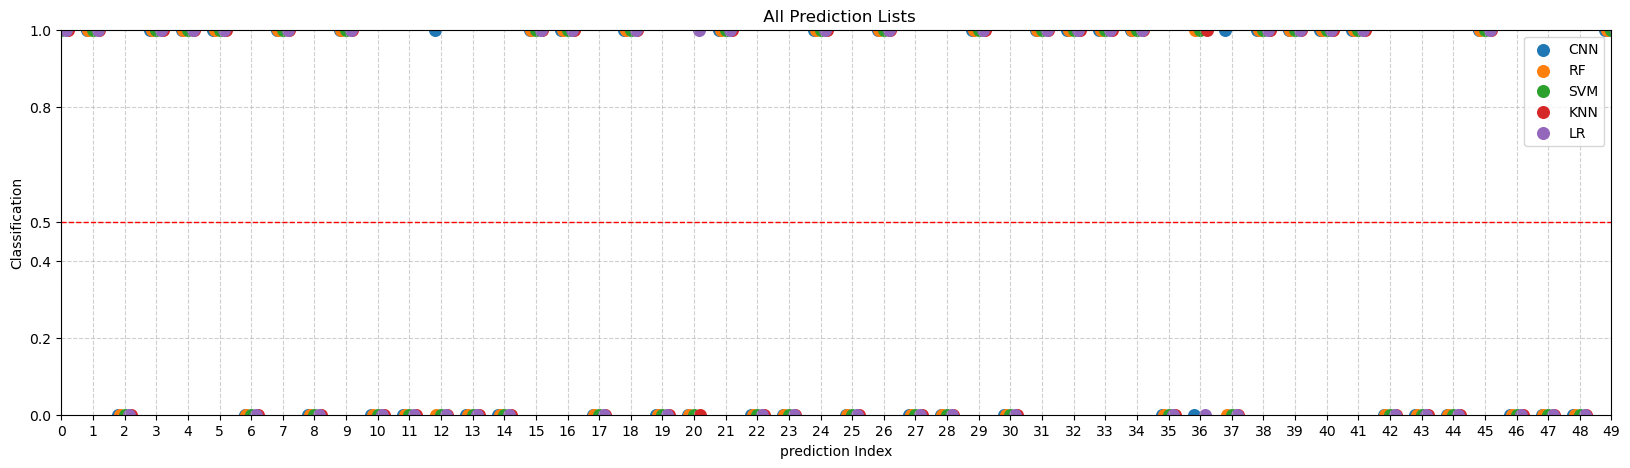

In [46]:
sze=np.arange(len(pred1))
plt.figure(figsize=(20,5))
plt.scatter(sze - 0.2, pred1, label='CNN', alpha=1, s=70)
plt.scatter(sze - 0.15, pred2, label='RF', alpha=1, s=70)
plt.scatter(sze, pred3, label='SVM', alpha=1, s=70)
plt.scatter(sze + 0.2, pred4, label='KNN', alpha=1, s=70)
plt.scatter(sze + 0.15 , pred5, label='LR', alpha=1, s=70)

plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1)

plt.ylim(0,1)
plt.xlim(0,10)
plt.xticks(range(0,50))
plt.yticks([0, 0.2,0.4,0.5,0.8,1])
plt.xlabel('prediction Index')
plt.ylabel('Classification')
plt.title(' All Prediction Lists')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


In [47]:
pp1=(cnn.predict(x_test_cnn)>0.5).astype('int').flatten()

X_test_hog1  = extract_hog_features1(x_test_ml.reshape(-1,200,200))
X_test_hog2  = extract_hog_features2(x_test_ml.reshape(-1,200,200))
X_test_hog3  = extract_hog_features3(x_test_ml.reshape(-1,200,200))
X_test_hog4  = extract_hog_features4(x_test_ml.reshape(-1,200,200))

pp2=rf.predict(X_test_hog1)
pp3=svm.predict(X_test_hog2)
pp4=knn.predict(X_test_hog3)
pp5=LR.predict(X_test_hog4)

25/25 [==============================] - 4s 139ms/step


In [48]:
total_prediction=[]
for i in range(len(pp3)):
    totaladd=pp1[i]+pp2[i]+pp3[i]+pp4[i]+pp5[i]
    total_prediction.append(totaladd)


In [49]:
Ensemble_prediction = [1 if val >= 3 else 0 for val in total_prediction]
print(Ensemble_prediction[:6])

[1, 1, 0, 1, 1, 1]


In [50]:
g=np.where(y_test != Ensemble_prediction)[0]
print(g)

[116 264 286 300 321 399 427 434 441 442 447 465 529 655 684 718 733]


In [51]:
print("Accuracy:", accuracy_score(y_test, Ensemble_prediction))
print("\nClassification Report:\n", classification_report(y_test, Ensemble_prediction))

Accuracy: 0.97875

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       400
           1       0.98      0.98      0.98       400

    accuracy                           0.98       800
   macro avg       0.98      0.98      0.98       800
weighted avg       0.98      0.98      0.98       800



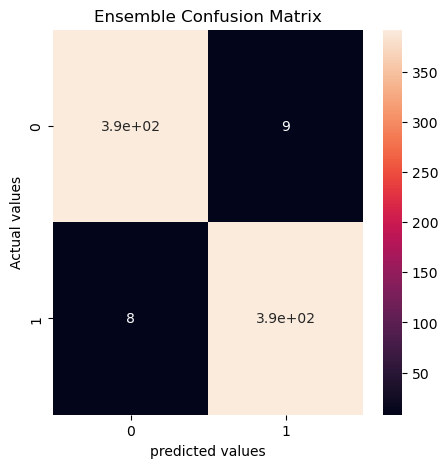

In [52]:
ensemble_confusion_matrix= confusion_matrix(y_test,Ensemble_prediction)
plt.figure(figsize=(5,5))
sn.heatmap(ensemble_confusion_matrix,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Ensemble Confusion Matrix")
plt.show()

In [53]:
img_path = '../external_pic/'  # Base folder
classes_in_dir = {'Brain_tumor_test': 1, 'healty_test': 0}

X, Y, filenames = [], [], []

# Load images
for cls in classes_in_dir:
    folder_path = os.path.join(img_path, cls)
    for file in os.listdir(folder_path):
        path = os.path.join(folder_path, file)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"Skipping {file}: cannot read image")
            continue
        img = cv2.resize(img, (200, 200))
        X.append(img)
        Y.append(classes_in_dir[cls])
        filenames.append(file)

x = np.array(X, dtype="float32")
y = np.array(Y)


In [54]:
# --------------------
# Predictions and counting
# --------------------
results = []
result_in_binary = []   # Ensemble votes
count_tumor = 0
count_healthy = 0

# Store individual model predictions
preds_cnn, preds_rf, preds_svm, preds_lr, preds_knn = [], [], [], [], []

for i, img in enumerate(x):
    file = filenames[i]

    # Prepare inputs
    img_cnn = img.reshape(1, 200, 200, 1) / 255.0
    img_flat = img.reshape(1, -1) / 255.0
   
   

    # Predictions
    pred_cnn = int((cnn.predict(img_cnn) > 0.5)[0][0])
    
    X_test_hog1=extract_hog_features1(img_flat.reshape(-1,200,200))
    X_test_hog2=extract_hog_features2(img_flat.reshape(-1,200,200))
    X_test_hog3=extract_hog_features3(img_flat.reshape(-1,200,200))
    X_test_hog4=extract_hog_features4(img_flat.reshape(-1,200,200))


    pred_rf  = rf.predict(X_test_hog1)[0]
    pred_svm = svm.predict( X_test_hog2)[0]
    pred_lr  = LR.predict( X_test_hog3)[0]
    pred_knn = knn.predict( X_test_hog4)[0]
   
    # Save individual predictions
    preds_cnn.append(pred_cnn)
    preds_rf.append(pred_rf)
    preds_svm.append(pred_svm)
    preds_lr.append(pred_lr)
    preds_knn.append(pred_knn)

    # Ensemble voting
    votes = pred_cnn + pred_rf + pred_svm + pred_lr + pred_knn
    final_binary = 1 if votes >= 3 else 0
    result_in_binary.append(final_binary)
    final_label = "Tumor" if final_binary == 1 else "Healthy"

    # Update counts
    if final_binary == 1:
        count_tumor += 1
    else:
        count_healthy += 1

    print(f"{file}: CNN={pred_cnn}, RF={pred_rf}, SVM={pred_svm}, LR={pred_lr}, KNN={pred_knn} -> Final: {final_label}")
    results.append((file, final_label))

# --------------------
# Summary
# --------------------
total = len(results)
result_in_binary = np.array(result_in_binary)

print("\n=== Summary ===")
print("Ensemble Accuracy:", accuracy_score(y, result_in_binary))
print("Ground truth counts:\n", pd.Series(y).value_counts())
print(f"Total images processed: {total}")
print(f"Tumor (predicted): {count_tumor}")
print(f"Healthy (predicted): {count_healthy}")

# --------------------
# Individual model accuracies
# --------------------
print("\n=== Individual Model Accuracies ===")
print("CNN Accuracy:", accuracy_score(y, preds_cnn))
print("RF Accuracy:", accuracy_score(y, preds_rf))
print("SVM Accuracy:", accuracy_score(y, preds_svm))
print("LR Accuracy:", accuracy_score(y, preds_lr))
print("KNN Accuracy:", accuracy_score(y, preds_knn))


1/1 [==============================] - 0s 53ms/step
PMA Meningiom (1).jpg: CNN=1, RF=1, SVM=1, LR=0, KNN=1 -> Final: Tumor
1/1 [==============================] - 0s 38ms/step
PMA Meningiom (10).jpg: CNN=1, RF=1, SVM=1, LR=1, KNN=1 -> Final: Tumor
1/1 [==============================] - 0s 42ms/step
PMA Meningiom (11).jpg: CNN=1, RF=1, SVM=1, LR=1, KNN=1 -> Final: Tumor
1/1 [==============================] - 0s 41ms/step
PMA Meningiom (12).jpg: CNN=1, RF=1, SVM=1, LR=1, KNN=1 -> Final: Tumor
1/1 [==============================] - 0s 36ms/step
PMA Meningiom (13).jpg: CNN=1, RF=1, SVM=1, LR=1, KNN=1 -> Final: Tumor
1/1 [==============================] - 0s 40ms/step
PMA Meningiom (14).jpg: CNN=1, RF=1, SVM=1, LR=1, KNN=1 -> Final: Tumor
1/1 [==============================] - 0s 36ms/step
PMA Meningiom (15).jpg: CNN=1, RF=1, SVM=1, LR=1, KNN=1 -> Final: Tumor
1/1 [==============================] - 0s 37ms/step
PMA Meningiom (16).jpg: CNN=1, RF=1, SVM=1, LR=1, KNN=1 -> Final: Tumor
1/1 [====

In [35]:
img_path2 = r"D:\My Final Work\external_pic/h5.jpeg" 
pic1 = cv2.imread(img_path2,0)  
pic1= cv2.resize(pic1, (200, 200))


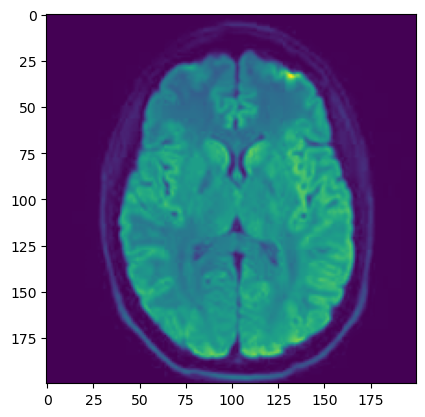

In [36]:
plt.imshow(pic1)

In [37]:
cnnpred1 = pic1.reshape(1, 200, 200, 1)
cnnpred = cnnpred1 / 255.0

In [38]:
cnnpred.shape

(1, 200, 200, 1)

In [39]:
p11 = (cnn.predict(cnnpred) > 0.5).astype('int').flatten()

1/1 [==============================] - 0s 35ms/step


In [40]:
print(p11)

[0]


In [41]:
p_2D=cnnpred.reshape(1, -1)
p_2D.shape

(1, 40000)

In [42]:
X_test_hog1=extract_hog_features1(p_2D.reshape(-1,200,200))
X_test_hog2=extract_hog_features2(p_2D.reshape(-1,200,200))
X_test_hog3=extract_hog_features3(p_2D.reshape(-1,200,200))
X_test_hog4=extract_hog_features4(p_2D.reshape(-1,200,200))

In [43]:
p22=rf.predict(X_test_hog1)
p33=svm.predict(X_test_hog2)
p44=LR.predict(X_test_hog3)
p55 = knn.predict(X_test_hog4)
print('CNN =',p11)
print('RF =',p22)
print('SVM =',p33)
print('LR =',p44)
print('KNN =',p55)

if(p11+p22+p33+p44+p55 >= 3):
    print(" \n Tumor")
elif (p11+p22+p33+p44+p55 < 3):
    print( "\n No Tumor")

CNN = [0]
RF = [0]
SVM = [0]
LR = [0]
KNN = [0]

 No Tumor
